1. Buid  a noise removal tool using gaussian median and mean filters and compare their effectiveness on salt pepper noise.

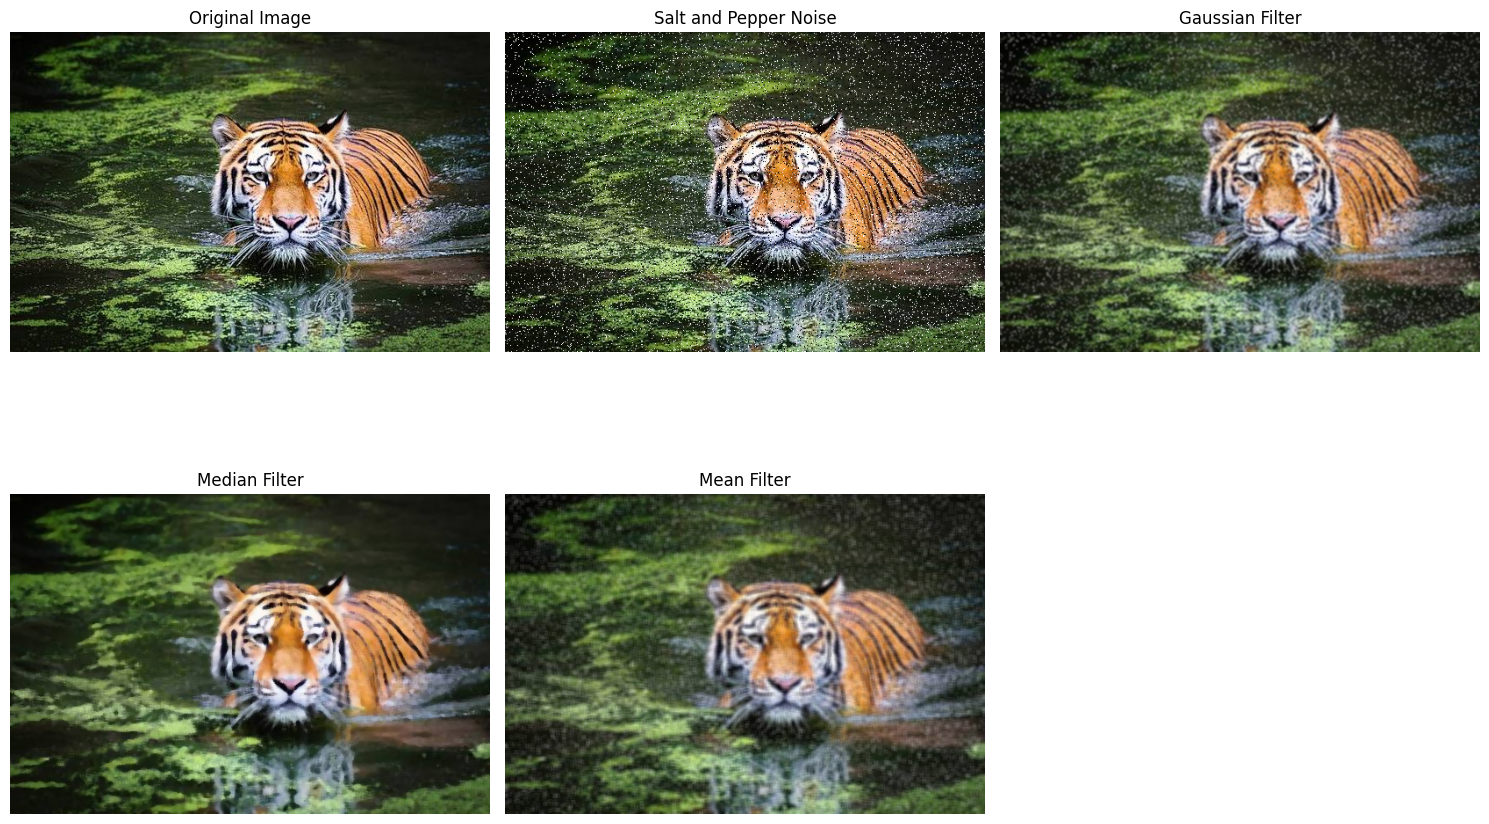


========== FILTER COMPARISON ==========

Gaussian Filter
MSE  : 641.36
PSNR : 20.06 dB

Median Filter
MSE  : 670.28
PSNR : 19.87 dB

Mean Filter
MSE  : 841.75
PSNR : 18.88 dB

Filtered images saved successfully!


In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Image
# ==========================================

image_path = "/content/sample_data/images.jpg"

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(
        "Image not found. Put input.jpg in the same folder."
    )

# Convert BGR to RGB
original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ==========================================
# 2. Add Salt and Pepper Noise
# ==========================================

def add_salt_pepper_noise(image, amount=0.05):
    noisy = image.copy()

    total_pixels = image.shape[0] * image.shape[1]
    num_pixels = int(amount * total_pixels)

    # Salt noise: white pixels
    rows = np.random.randint(0, image.shape[0], num_pixels)
    cols = np.random.randint(0, image.shape[1], num_pixels)

    noisy[rows, cols] = 255

    # Pepper noise: black pixels
    rows = np.random.randint(0, image.shape[0], num_pixels)
    cols = np.random.randint(0, image.shape[1], num_pixels)

    noisy[rows, cols] = 0

    return noisy


np.random.seed(42)

noisy_image = add_salt_pepper_noise(original, amount=0.05)


# ==========================================
# 3. Apply Filters
# ==========================================

# Gaussian Filter
gaussian = cv2.GaussianBlur(
    noisy_image,
    (5, 5),
    0
)

# Median Filter
median = cv2.medianBlur(
    noisy_image,
    5
)

# Mean Filter
mean = cv2.blur(
    noisy_image,
    (5, 5)
)


# ==========================================
# 4. Calculate MSE and PSNR
# ==========================================

def calculate_mse(original, filtered):
    mse = np.mean(
        (original.astype(np.float32)
         - filtered.astype(np.float32)) ** 2
    )
    return mse


def calculate_psnr(original, filtered):
    mse = calculate_mse(original, filtered)

    if mse == 0:
        return float("inf")

    return 10 * np.log10((255 ** 2) / mse)


filters = {
    "Gaussian": gaussian,
    "Median": median,
    "Mean": mean
}


# ==========================================
# 5. Display Results
# ==========================================

plt.figure(figsize=(15, 10))

images = [
    original,
    noisy_image,
    gaussian,
    median,
    mean
]

titles = [
    "Original Image",
    "Salt and Pepper Noise",
    "Gaussian Filter",
    "Median Filter",
    "Mean Filter"
]

for i in range(len(images)):
    plt.subplot(2, 3, i + 1)

    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


# ==========================================
# 6. Print Comparison
# ==========================================

print("\n========== FILTER COMPARISON ==========")

for name, result in filters.items():

    mse = calculate_mse(original, result)
    psnr = calculate_psnr(original, result)

    print(f"\n{name} Filter")
    print(f"MSE  : {mse:.2f}")
    print(f"PSNR : {psnr:.2f} dB")


# ==========================================
# 7. Save Filtered Images
# ==========================================

cv2.imwrite(
    "gaussian_filtered.jpg",
    cv2.cvtColor(gaussian, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    "median_filtered.jpg",
    cv2.cvtColor(median, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    "mean_filtered.jpg",
    cv2.cvtColor(mean, cv2.COLOR_RGB2BGR)
)

print("\nFiltered images saved successfully!")

2.Develop an edge detection demo using high pass filters (laplacian and sobel kernels) and visualize the resulting edge maps.


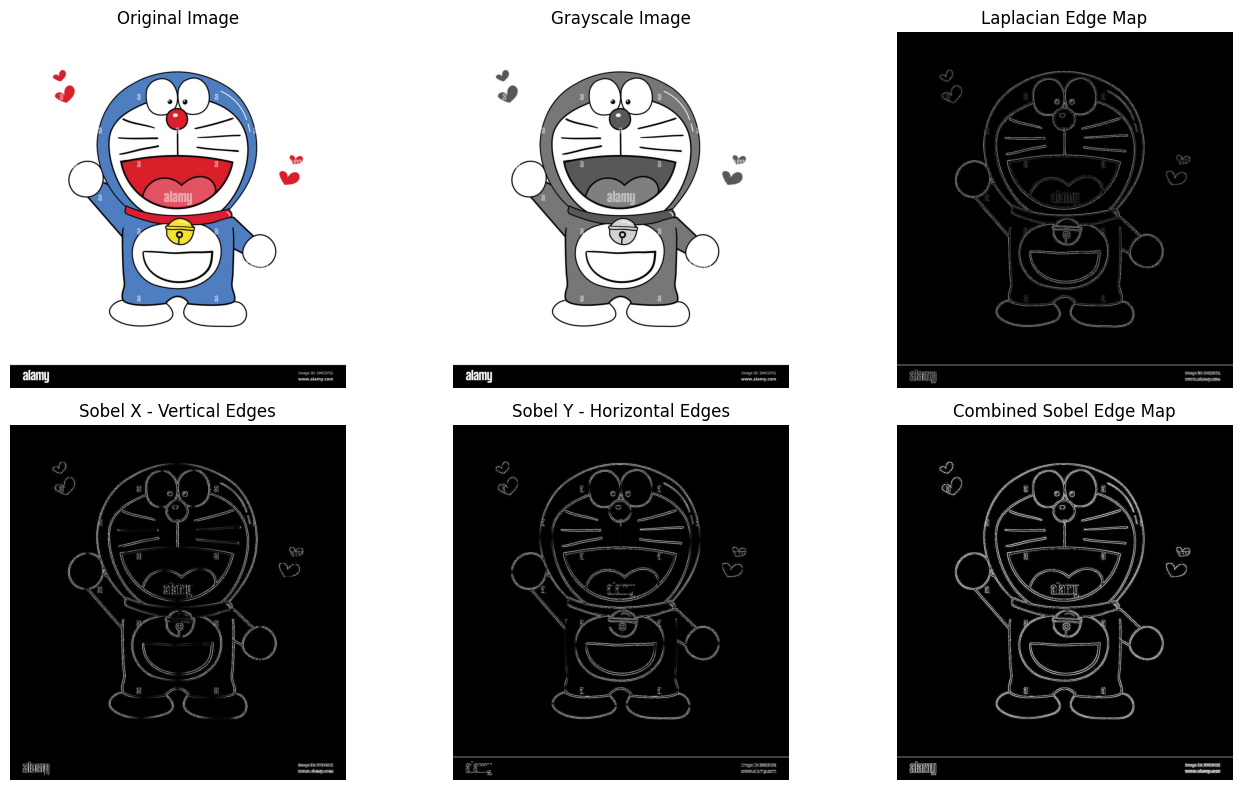

Edge detection completed successfully!
Edge maps saved in the project folder.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Image
# ==========================================

image_path = "/content/sample_data/doraemon image.jpg"

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(
        "input.jpg not found. Put the image in the same folder."
    )

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# ==========================================
# 2. Laplacian High-Pass Filter
# ==========================================

laplacian = cv2.Laplacian(
    gray,
    cv2.CV_64F
)

# Convert to displayable image
laplacian = np.uint8(
    np.absolute(laplacian)
)


# ==========================================
# 3. Sobel High-Pass Filter
# ==========================================

# Sobel X
sobel_x = cv2.Sobel(
    gray,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

# Sobel Y
sobel_y = cv2.Sobel(
    gray,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

# Convert to absolute values
sobel_x = np.uint8(np.absolute(sobel_x))
sobel_y = np.uint8(np.absolute(sobel_y))

# Combine X and Y
sobel = cv2.magnitude(
    sobel_x.astype(np.float32),
    sobel_y.astype(np.float32)
)

sobel = np.uint8(
    np.clip(sobel, 0, 255)
)


# ==========================================
# 4. Display Edge Maps
# ==========================================

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian Edge Map")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel_x, cmap="gray")
plt.title("Sobel X - Vertical Edges")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sobel_y, cmap="gray")
plt.title("Sobel Y - Horizontal Edges")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(sobel, cmap="gray")
plt.title("Combined Sobel Edge Map")
plt.axis("off")

plt.tight_layout()
plt.show()


# ==========================================
# 5. Save Edge Maps
# ==========================================

cv2.imwrite(
    "laplacian_edges.jpg",
    laplacian
)

cv2.imwrite(
    "sobel_x_edges.jpg",
    sobel_x
)

cv2.imwrite(
    "sobel_y_edges.jpg",
    sobel_y
)

cv2.imwrite(
    "sobel_combined_edges.jpg",
    sobel
)

print("Edge detection completed successfully!")
print("Edge maps saved in the project folder.")

3.Create an interactive blur tool with an  adjustable kernel size for real time low pass filtering.

Please upload an image:


Saving download.png to download (1).png

Uploaded Image: download (1).png
Image loaded successfully!


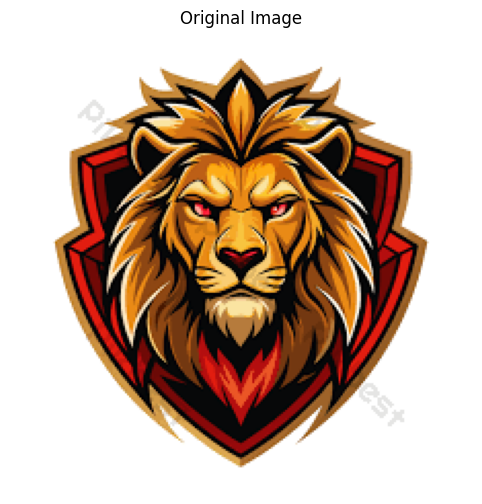


       INTERACTIVE BLUR TOOL

Available Kernel Sizes:
1  = No Blur
3  = Slight Blur
5  = Moderate Blur
7  = More Blur
9  = Strong Blur
11 = Stronger Blur
15 = Very Strong Blur
21 = Maximum Blur

Enter Kernel Size (1, 3, 5, 7, 9, 11, 15, 21): 11


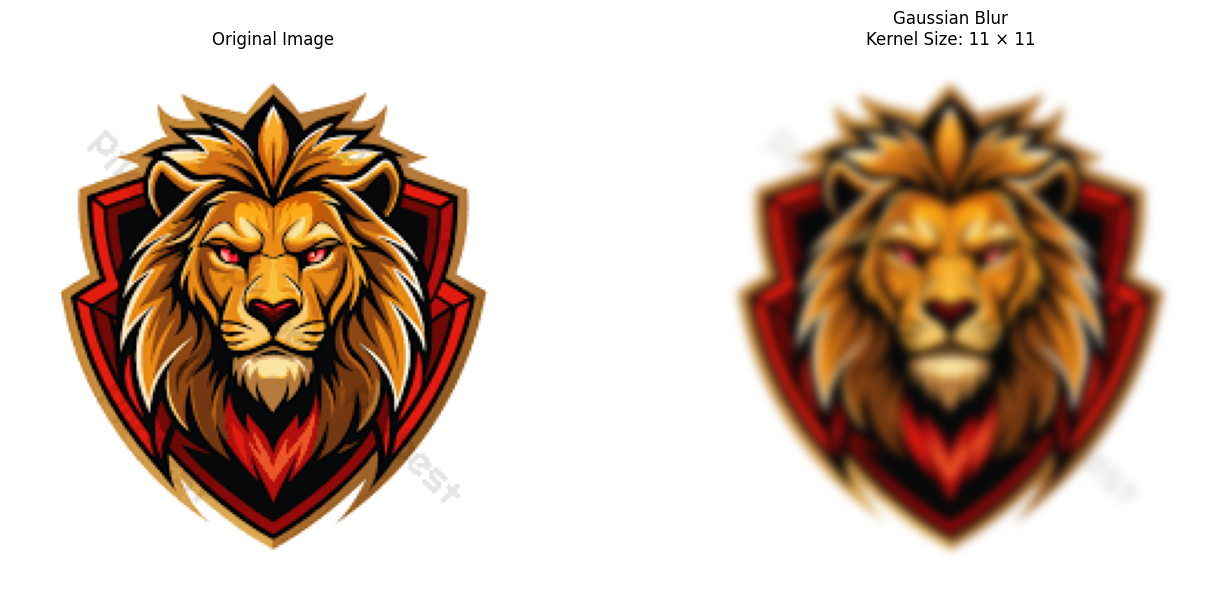


Blurred image saved as: blurred_11x11.jpg

           RESULT
Selected Kernel: 11 × 11
Effect: Strong blur

Low-pass filtering reduces:
- Noise
- Fine details
- Sharp high-frequency components


In [ ]:
# ============================================================
# INTERACTIVE BLUR TOOL
# Adjustable Kernel Size for Low-Pass Filtering
# ============================================================

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 1. UPLOAD IMAGE
# ============================================================

print("Please upload an image:")

uploaded = files.upload()

image_name = next(iter(uploaded))

print("\nUploaded Image:", image_name)


# ============================================================
# 2. READ IMAGE
# ============================================================

image = cv2.imread(image_name)

if image is None:
    print("ERROR: Image could not be loaded.")
else:

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    print("Image loaded successfully!")


    # ========================================================
    # 3. DISPLAY ORIGINAL IMAGE
    # ========================================================

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()


    # ========================================================
    # 4. ASK FOR KERNEL SIZE
    # ========================================================

    print("\n======================================")
    print("       INTERACTIVE BLUR TOOL")
    print("======================================")

    print("\nAvailable Kernel Sizes:")
    print("1  = No Blur")
    print("3  = Slight Blur")
    print("5  = Moderate Blur")
    print("7  = More Blur")
    print("9  = Strong Blur")
    print("11 = Stronger Blur")
    print("15 = Very Strong Blur")
    print("21 = Maximum Blur")

    kernel = int(input("\nEnter Kernel Size (1, 3, 5, 7, 9, 11, 15, 21): "))


    # ========================================================
    # 5. CHECK KERNEL SIZE
    # ========================================================

    if kernel < 1:
        kernel = 1

    # Kernel must be odd
    if kernel % 2 == 0:
        kernel += 1

    if kernel > 21:
        kernel = 21


    # ========================================================
    # 6. APPLY GAUSSIAN BLUR
    # ========================================================

    blurred_image = cv2.GaussianBlur(
        image,
        (kernel, kernel),
        0
    )


    # ========================================================
    # 7. DISPLAY ORIGINAL + BLURRED IMAGE
    # ========================================================

    plt.figure(figsize=(14, 6))


    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")


    # Blurred
    plt.subplot(1, 2, 2)
    plt.imshow(blurred_image)
    plt.title(
        f"Gaussian Blur\nKernel Size: {kernel} × {kernel}"
    )
    plt.axis("off")


    plt.tight_layout()
    plt.show()


    # ========================================================
    # 8. SAVE BLURRED IMAGE
    # ========================================================

    output_name = f"blurred_{kernel}x{kernel}.jpg"

    # RGB → BGR
    blurred_bgr = cv2.cvtColor(
        blurred_image,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(output_name, blurred_bgr)

    print("\nBlurred image saved as:", output_name)


    # ========================================================
    # 9. INFORMATION
    # ========================================================

    print("\n======================================")
    print("           RESULT")
    print("======================================")

    print("Selected Kernel:", kernel, "×", kernel)

    if kernel == 1:
        print("Effect: No blur")
    elif kernel <= 5:
        print("Effect: Slight / Moderate blur")
    elif kernel <= 11:
        print("Effect: Strong blur")
    else:
        print("Effect: Very strong blur")

    print("\nLow-pass filtering reduces:")
    print("- Noise")
    print("- Fine details")
    print("- Sharp high-frequency components")

4. Build a sharpening tool that applies unsharp masking to enhance fine details in  an image.

Please upload an image:


Saving ballon image.jpg to ballon image (1).jpg

Uploaded Image: ballon image (1).jpg
Image loaded successfully!


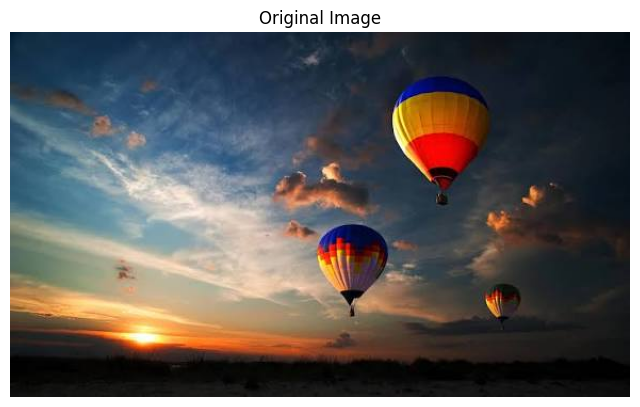

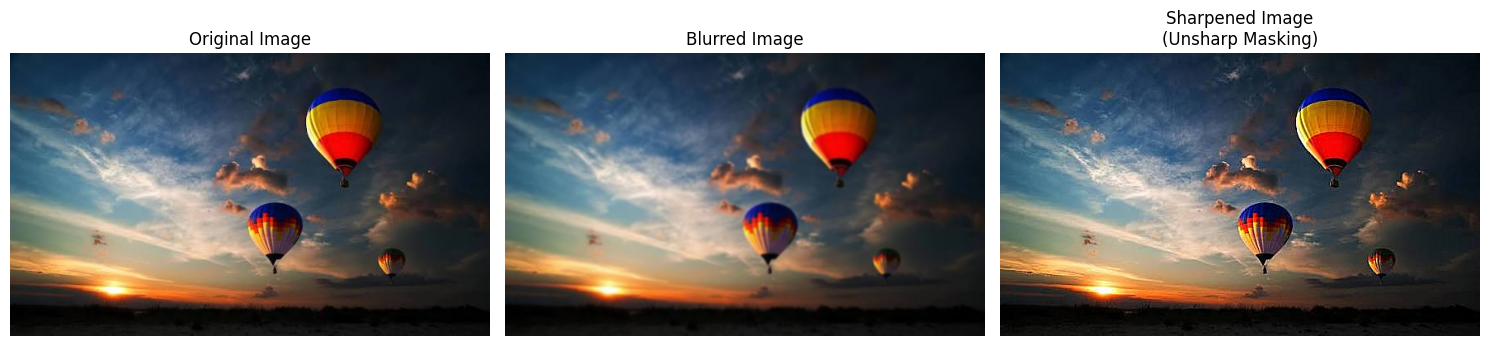


Sharpened image saved as: sharpened_image.jpg


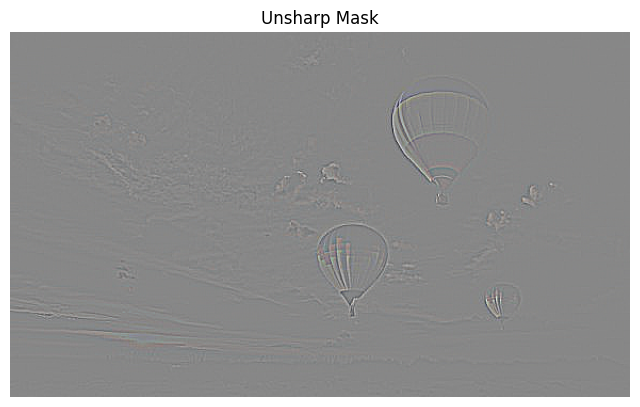


       UNSHARP MASKING RESULT
Blur Kernel Size : 5 × 5
Sharpening Amount: 1.5

Unsharp Masking:
1. Blur the original image
2. Calculate Original - Blurred
3. Add the mask to the original image
4. Fine details and edges become sharper


In [ ]:
# ============================================================
# LAB 4: IMAGE SHARPENING USING UNSHARP MASKING
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


# ============================================================
# 1. UPLOAD IMAGE
# ============================================================

print("Please upload an image:")

uploaded = files.upload()

image_name = next(iter(uploaded))

print("\nUploaded Image:", image_name)


# ============================================================
# 2. READ IMAGE
# ============================================================

image = cv2.imread(image_name)

if image is None:
    raise ValueError("Image could not be loaded.")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image loaded successfully!")


# ============================================================
# 3. DISPLAY ORIGINAL IMAGE
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.show()


# ============================================================
# 4. CONVERT IMAGE TO FLOAT
# ============================================================

image_float = image.astype(np.float32)


# ============================================================
# 5. CREATE BLURRED IMAGE
# ============================================================

# Gaussian blur
blurred = cv2.GaussianBlur(
    image_float,
    (5, 5),
    0
)


# ============================================================
# 6. CREATE UNSHARP MASK
# ============================================================

# Difference between original and blurred image
unsharp_mask = image_float - blurred


# ============================================================
# 7. SHARPEN THE IMAGE
# ============================================================

# Sharpening strength
amount = 1.5

sharpened = image_float + amount * unsharp_mask


# ============================================================
# 8. CLIP PIXEL VALUES
# ============================================================

sharpened = np.clip(
    sharpened,
    0,
    255
).astype(np.uint8)


# ============================================================
# 9. DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(15, 5))


# Original
plt.subplot(1, 3, 1)

plt.imshow(image)

plt.title("Original Image")

plt.axis("off")


# Blurred
plt.subplot(1, 3, 2)

plt.imshow(blurred.astype(np.uint8))

plt.title("Blurred Image")

plt.axis("off")


# Sharpened
plt.subplot(1, 3, 3)

plt.imshow(sharpened)

plt.title("Sharpened Image\n(Unsharp Masking)")

plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# 10. SAVE SHARPENED IMAGE
# ============================================================

output_name = "sharpened_image.jpg"

# RGB → BGR
sharpened_bgr = cv2.cvtColor(
    sharpened,
    cv2.COLOR_RGB2BGR
)

cv2.imwrite(
    output_name,
    sharpened_bgr
)

print("\nSharpened image saved as:", output_name)


# ============================================================
# 11. DISPLAY UNSHARP MASK
# ============================================================

# Convert mask to visible form
mask_display = cv2.normalize(
    unsharp_mask,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


plt.figure(figsize=(8, 6))

plt.imshow(mask_display)

plt.title("Unsharp Mask")

plt.axis("off")

plt.show()


# ============================================================
# 12. INFORMATION
# ============================================================

print("\n==========================================")
print("       UNSHARP MASKING RESULT")
print("==========================================")

print("Blur Kernel Size : 5 × 5")
print("Sharpening Amount: 1.5")

print("\nUnsharp Masking:")
print("1. Blur the original image")
print("2. Calculate Original - Blurred")
print("3. Add the mask to the original image")
print("4. Fine details and edges become sharper")

5. Develop a custom convolution  kernel designer where users input their own kernelmatrix and apply it to an image.

       CUSTOM KERNEL DESIGNER

Please upload an image:


Saving doraemon image.jpg to doraemon image.jpg

Uploaded Image: doraemon image.jpg
Image loaded successfully!


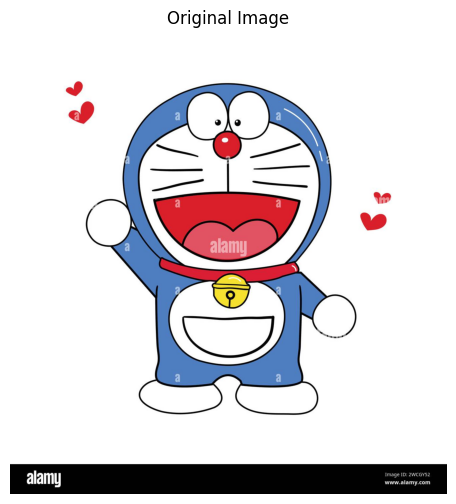


           KERNEL SIZE
You can use:
3 = 3 × 3 Kernel
5 = 5 × 5 Kernel
7 = 7 × 7 Kernel

Enter kernel size (3, 5 or 7): 5

     ENTER 5 × 5 KERNEL
Enter 5 numbers for each row.
Example for 3 × 3:
0 -1  0
-1 5 -1
0 -1  0
Enter row 1: 0 -1 0
Please enter exactly 5 numbers.
Enter row 1: 4
Please enter exactly 5 numbers.
Enter row 1: 0 -1 0
Please enter exactly 5 numbers.
Enter row 1: 0 0 -1 0 0
Enter row 2: 0 -1 -1 -1 0
Enter row 3: -1 -1 9 -1 -1
Enter row 4: 0 -1 -1 -1 0
Enter row 5:  0 0 -1 0 0

          YOUR CUSTOM KERNEL
[[ 0.  0. -1.  0.  0.]
 [ 0. -1. -1. -1.  0.]
 [-1. -1.  9. -1. -1.]
 [ 0. -1. -1. -1.  0.]
 [ 0.  0. -1.  0.  0.]]


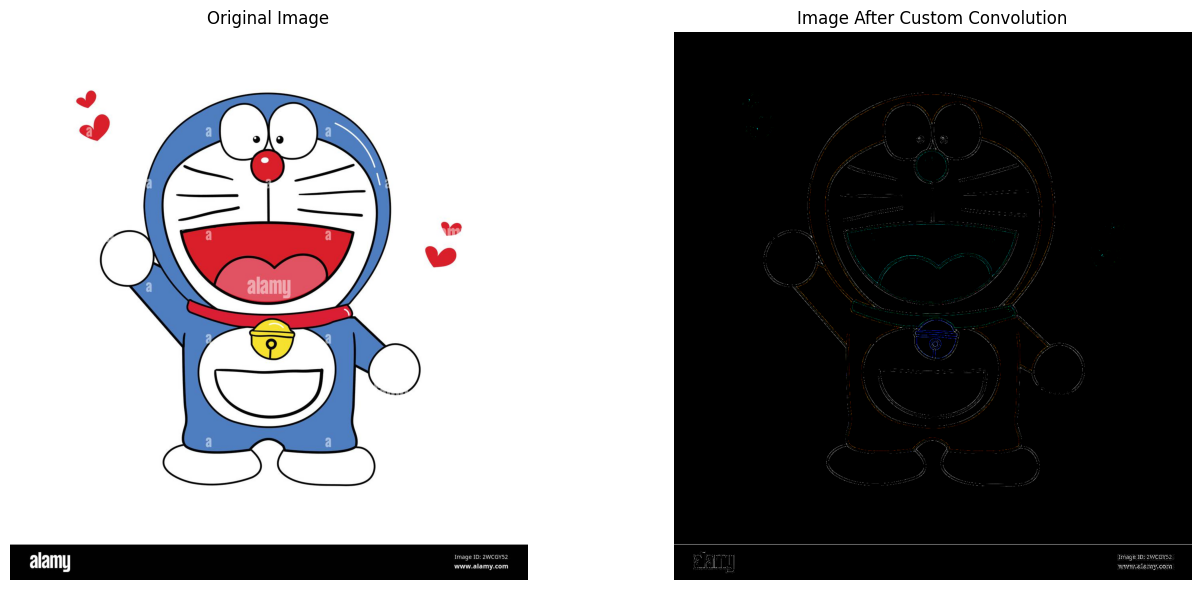


Output saved as: custom_kernel_output.jpg

             RESULT
Kernel Size: 5 × 5

Custom kernel successfully applied!

You can try different kernels:

Sharpening:
0 -1  0
-1 5 -1
0 -1  0

Edge Detection:
-1 -1 -1
-1  8 -1
-1 -1 -1

Blur:
1/9 1/9 1/9
1/9 1/9 1/9
1/9 1/9 1/9


In [ ]:
# ============================================================
# LAB 5: CUSTOM CONVOLUTION KERNEL DESIGNER
# User can enter their own kernel matrix and apply it to image
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


# ============================================================
# 1. UPLOAD IMAGE
# ============================================================

print("==========================================")
print("       CUSTOM KERNEL DESIGNER")
print("==========================================")

print("\nPlease upload an image:")

uploaded = files.upload()

image_name = next(iter(uploaded))

print("\nUploaded Image:", image_name)


# ============================================================
# 2. READ IMAGE
# ============================================================

image = cv2.imread(image_name)

if image is None:
    raise ValueError("Image could not be loaded.")

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image loaded successfully!")


# ============================================================
# 3. DISPLAY ORIGINAL IMAGE
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(image_rgb)

plt.title("Original Image")

plt.axis("off")

plt.show()


# ============================================================
# 4. SELECT KERNEL SIZE
# ============================================================

print("\n==========================================")
print("           KERNEL SIZE")
print("==========================================")

print("You can use:")
print("3 = 3 × 3 Kernel")
print("5 = 5 × 5 Kernel")
print("7 = 7 × 7 Kernel")

kernel_size = int(
    input("\nEnter kernel size (3, 5 or 7): ")
)


# Check kernel size
if kernel_size not in [3, 5, 7]:
    print("Invalid size! Using 3 × 3 kernel.")
    kernel_size = 3


# ============================================================
# 5. ENTER CUSTOM KERNEL
# ============================================================

print("\n==========================================")
print(f"     ENTER {kernel_size} × {kernel_size} KERNEL")
print("==========================================")

print(
    f"Enter {kernel_size} numbers for each row."
)

print("Example for 3 × 3:")
print("0 -1  0")
print("-1 5 -1")
print("0 -1  0")


kernel = []

for i in range(kernel_size):

    while True:

        row = input(
            f"Enter row {i + 1}: "
        ).split()

        if len(row) != kernel_size:

            print(
                f"Please enter exactly {kernel_size} numbers."
            )

        else:

            try:

                row = [float(x) for x in row]

                kernel.append(row)

                break

            except ValueError:

                print(
                    "Please enter numbers only."
                )


# Convert to NumPy array
kernel = np.array(
    kernel,
    dtype=np.float32
)


# ============================================================
# 6. DISPLAY CUSTOM KERNEL
# ============================================================

print("\n==========================================")
print("          YOUR CUSTOM KERNEL")
print("==========================================")

print(kernel)


# ============================================================
# 7. APPLY CONVOLUTION
# ============================================================

# Convert image to float32
image_float = image_rgb.astype(np.float32)


# Apply kernel separately to RGB channels
result = cv2.filter2D(
    image_float,
    -1,
    kernel
)


# ============================================================
# 8. NORMALIZE RESULT
# ============================================================

result = np.clip(
    result,
    0,
    255
).astype(np.uint8)


# ============================================================
# 9. DISPLAY ORIGINAL AND RESULT
# ============================================================

plt.figure(figsize=(14, 6))


# Original image
plt.subplot(1, 2, 1)

plt.imshow(image_rgb)

plt.title("Original Image")

plt.axis("off")


# Convolution result
plt.subplot(1, 2, 2)

plt.imshow(result)

plt.title("Image After Custom Convolution")

plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# 10. SAVE RESULT
# ============================================================

output_name = "custom_kernel_output.jpg"

# RGB → BGR
result_bgr = cv2.cvtColor(
    result,
    cv2.COLOR_RGB2BGR
)

cv2.imwrite(
    output_name,
    result_bgr
)

print("\nOutput saved as:", output_name)


# ============================================================
# 11. KERNEL EFFECT INFORMATION
# ============================================================

print("\n==========================================")
print("             RESULT")
print("==========================================")

print("Kernel Size:", kernel_size, "×", kernel_size)

print("\nCustom kernel successfully applied!")

print("\nYou can try different kernels:")
print("\nSharpening:")
print("0 -1  0")
print("-1 5 -1")
print("0 -1  0")

print("\nEdge Detection:")
print("-1 -1 -1")
print("-1  8 -1")
print("-1 -1 -1")

print("\nBlur:")
print("1/9 1/9 1/9")
print("1/9 1/9 1/9")
print("1/9 1/9 1/9")

6.Create a bilateral filtering demo that smooths an image while preserving edges and compre it with standard gaussian blur.

Saving shuzikaa image.jpg to shuzikaa image.jpg


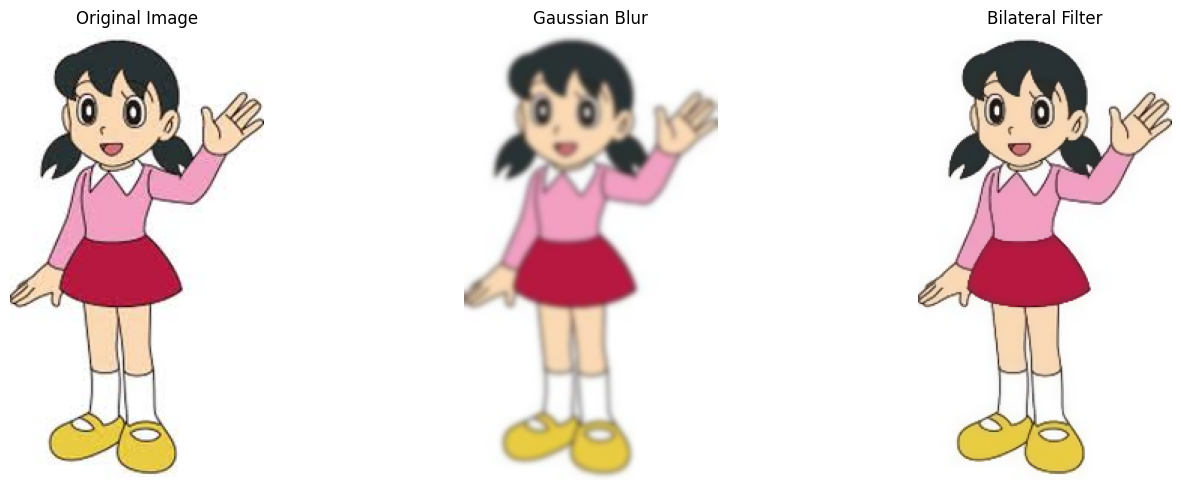

Gaussian Blur saved as: gaussian_blur.jpg
Bilateral Filter saved as: bilateral_filter.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==============================
# 1. Upload Image
# ==============================
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
image = cv2.imread(filename)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ==============================
# 2. Gaussian Blur
# ==============================
gaussian = cv2.GaussianBlur(image_rgb, (9, 9), 0)

# ==============================
# 3. Bilateral Filtering
# ==============================
bilateral = cv2.bilateralFilter(
    image_rgb,
    d=9,
    sigmaColor=75,
    sigmaSpace=75
)

# ==============================
# 4. Display Comparison
# ==============================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilateral)
plt.title("Bilateral Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 5. Save Results
# ==============================
cv2.imwrite(
    "gaussian_blur.jpg",
    cv2.cvtColor(gaussian, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    "bilateral_filter.jpg",
    cv2.cvtColor(bilateral, cv2.COLOR_RGB2BGR)
)

print("Gaussian Blur saved as: gaussian_blur.jpg")
print("Bilateral Filter saved as: bilateral_filter.jpg")

8. Develop a program that reduces simple motion  blur  artifacts  using high pass sharpening  techniques.

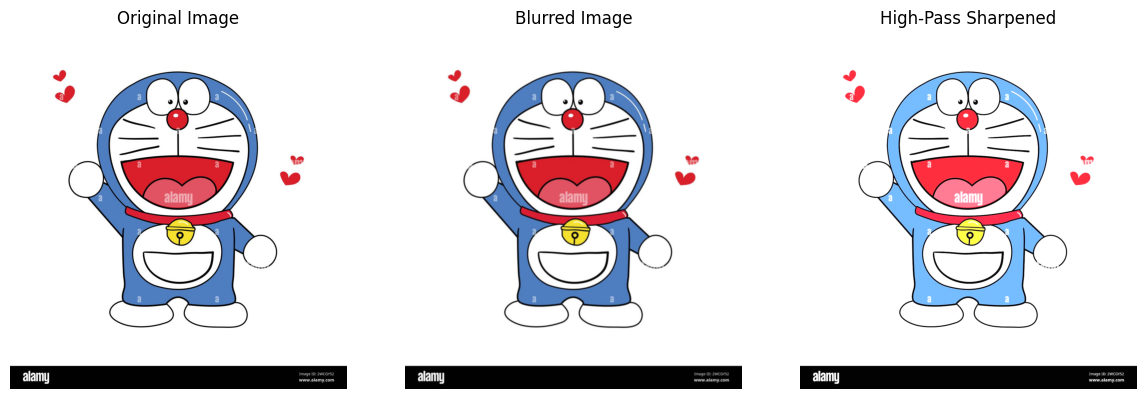

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/sample_data/doraemon image.jpg")

# Convert BGR to RGB for displaying
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Create Gaussian blurred image
blur = cv2.GaussianBlur(img, (5, 5), 0)

# High-pass sharpening
# Original - blurred = high-frequency details
high_pass = cv2.subtract(img, blur)

# Add high-frequency details to original image
sharpened = cv2.addWeighted(img, 1.5, high_pass, 1.0, 0)

# Convert sharpened image to RGB
sharpened_rgb = cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened_rgb)
plt.title("High-Pass Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()

9. Create a "catoonify" effect generator using edge detection combined with smoothing filters.

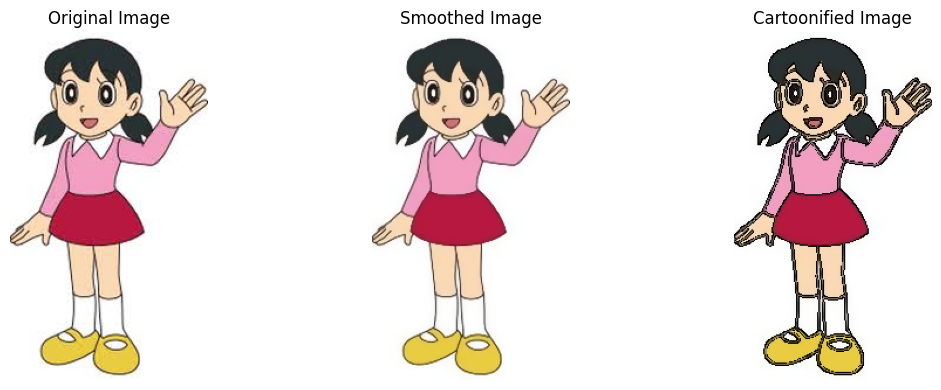

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/sample_data/shuzikaa image.jpg")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 1: Smooth the image
smooth = cv2.bilateralFilter(img, 9, 75, 75)

# Step 2: Convert image to grayscale
gray = cv2.cvtColor(smooth, cv2.COLOR_BGR2GRAY)

# Step 3: Detect edges
edges = cv2.Canny(gray, 50, 150)

# Step 4: Invert the edges
edges = cv2.bitwise_not(edges)

# Step 5: Convert edges to 3 channels
edges = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

# Step 6: Combine smoothing and edges
cartoon = cv2.bitwise_and(
    cv2.cvtColor(smooth, cv2.COLOR_BGR2RGB),
    edges
)

# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(smooth, cv2.COLOR_BGR2RGB))
plt.title("Smoothed Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cartoon)
plt.title("Cartoonified Image")
plt.axis("off")

plt.tight_layout()
plt.show()

10. Buid a comparsion dashboard that reports PSNR/SSIM for different filtering techniques applied to the same noisy image.


Filtering Performance Comparison
-------------------------------------------------------
Filter               PSNR         SSIM        
-------------------------------------------------------
Mean Filter               18.84 dB     0.6846
Gaussian Filter           20.98 dB     0.7686
Median Filter             20.17 dB     0.7256
Bilateral Filter          22.40 dB     0.8229
-------------------------------------------------------


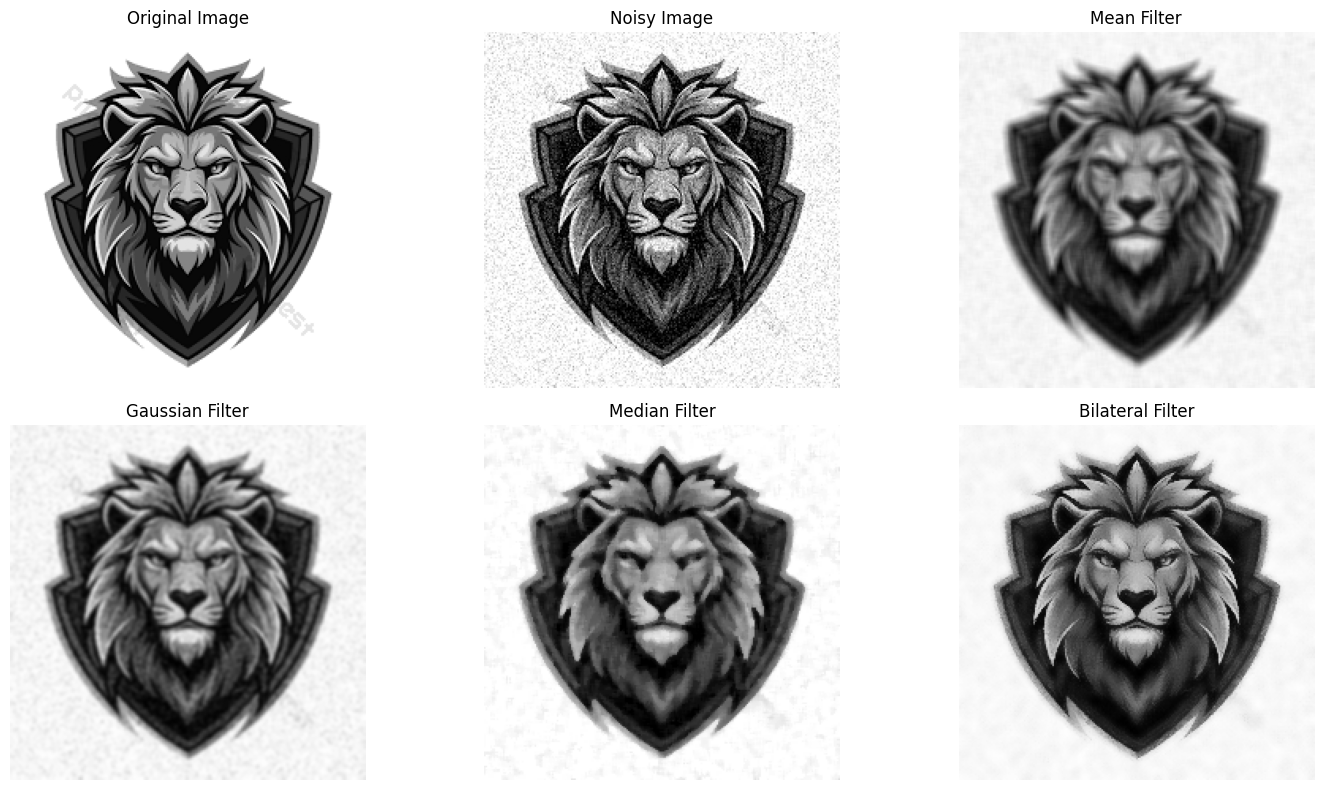

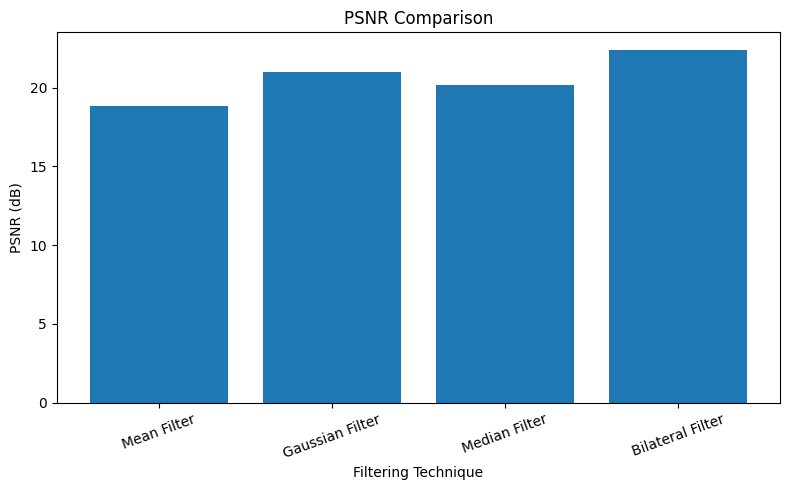

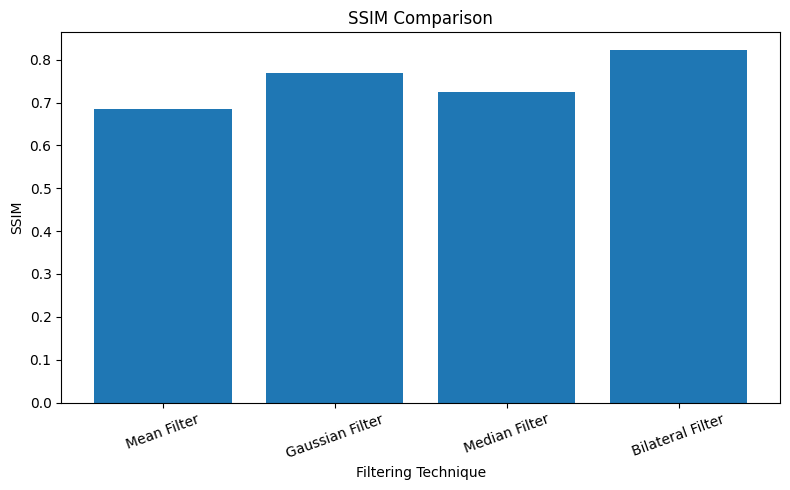

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SSIM Function
# -----------------------------
def calculate_ssim(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    C1 = (0.01 * 255) ** 2
    C2 = (0.03 * 255) ** 2

    mu1 = cv2.GaussianBlur(img1, (11, 11), 1.5)
    mu2 = cv2.GaussianBlur(img2, (11, 11), 1.5)

    mu1_sq = mu1 * mu1
    mu2_sq = mu2 * mu2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = cv2.GaussianBlur(img1 * img1, (11, 11), 1.5) - mu1_sq
    sigma2_sq = cv2.GaussianBlur(img2 * img2, (11, 11), 1.5) - mu2_sq
    sigma12 = cv2.GaussianBlur(img1 * img2, (11, 11), 1.5) - mu1_mu2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) *
                (sigma1_sq + sigma2_sq + C2))

    return ssim_map.mean()


# -----------------------------
# Read Original Image
# -----------------------------
original = cv2.imread("/content/download.png")

if original is None:
    print("Image not found!")
    exit()

original = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Add Gaussian Noise
# -----------------------------
noise = np.random.normal(0, 25, original.shape)
noisy = original.astype(np.float32) + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

# -----------------------------
# Apply Different Filters
# -----------------------------

# 1. Mean Filter
mean_filter = cv2.blur(noisy, (5, 5))

# 2. Gaussian Filter
gaussian_filter = cv2.GaussianBlur(noisy, (5, 5), 0)

# 3. Median Filter
median_filter = cv2.medianBlur(noisy, 5)

# 4. Bilateral Filter
bilateral_filter = cv2.bilateralFilter(noisy, 9, 75, 75)

# Store results
results = {
    "Mean Filter": mean_filter,
    "Gaussian Filter": gaussian_filter,
    "Median Filter": median_filter,
    "Bilateral Filter": bilateral_filter
}

# -----------------------------
# Calculate PSNR and SSIM
# -----------------------------

print("\nFiltering Performance Comparison")
print("-" * 55)
print(f"{'Filter':20} {'PSNR':12} {'SSIM':12}")
print("-" * 55)

psnr_values = []
ssim_values = []

for name, filtered in results.items():

    psnr = cv2.PSNR(original, filtered)
    ssim = calculate_ssim(original, filtered)

    psnr_values.append(psnr)
    ssim_values.append(ssim)

    print(f"{name:20} {psnr:10.2f} dB {ssim:10.4f}")

print("-" * 55)

# -----------------------------
# Display Images
# -----------------------------

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(original, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

i = 3

for name, filtered in results.items():
    plt.subplot(2, 3, i)
    plt.imshow(filtered, cmap="gray")
    plt.title(name)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

# -----------------------------
# PSNR Comparison
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(results.keys(), psnr_values)
plt.ylabel("PSNR (dB)")
plt.xlabel("Filtering Technique")
plt.title("PSNR Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# -----------------------------
# SSIM Comparison
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(results.keys(), ssim_values)
plt.ylabel("SSIM")
plt.xlabel("Filtering Technique")
plt.title("SSIM Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()